# 25 · Domain Decomposition on Overthrust 3-D

A real 3-D benchmark split across GPUs. `ModelParallel` slices **one** model into
tiles — one per GPU — and exchanges a thin halo every time step, so a single shot
is solved cooperatively rather than replicated.

The point of this notebook is not "DD runs" but **DD gives the same answer**: the
record and the gradient are checked against the single-domain result, and the
gradient is plotted across the cut lines where a halo bug would show up.

> **DD needs one process per tile.** A notebook is a single process, so the
> multi-tile part is launched as a subprocess with `torch.distributed.run`
> (that is what `torchrun` is). The `world=1` path below runs inline.


In [1]:
import numpy as np, torch, sweep
from sweep.datasets import load
from sweep.parallel import pad_to_mesh

print("sweep:", sweep.__file__)
print("GPUs :", torch.cuda.device_count())

# Overthrust 3-D, decimated 2x -> 94 x 401 x 401 @ 50 m (fits one V100 for the
# single-domain reference; DD then splits it py x px).
d  = load("overthrust", variant="3d-acoustic", downsample=2)
vp = np.ascontiguousarray(d["vp"]).astype("float32")
dh = float(d["dh"][0])

# DD v1 slices into UNIFORM tiles, so each split axis must divide evenly by the
# tile count. Overthrust is 401 wide, which 2 and 4 do not divide. Pad -- do
# NOT crop: cropping would silently solve a different, smaller problem.
#
# `pad_to_mesh` pads the HIGH side only (source/receiver indices stay valid)
# and replicates the edge, so the added columns carry no impedance contrast
# and generate no artificial reflection. It is also differentiable: in an
# inversion you keep the UNPADDED model as the optimisation variable and pad
# inside the closure -- gradients on the invented cells flow back onto the
# edge (see test/dd_pad_grad_check.py). Here we pad once for the largest mesh
# factor we intend to use.
TILE = 4
vp_raw = vp
vp = pad_to_mesh(vp, py=TILE, px=TILE)
pad_y, pad_x = vp.shape[1] - vp_raw.shape[1], vp.shape[2] - vp_raw.shape[2]
print("vp", vp_raw.shape, "->", vp.shape,
      f"(edge-padded +{pad_y} in y, +{pad_x} in x for {TILE}-way tiles)")
print(f"   {vp.min():.0f}-{vp.max():.0f} m/s   dh={dh:.0f} m")

sweep: /ibex/user/wangs0j/sweep_merge_verify/src/src/sweep/__init__.py
GPUs : 4
[sweep.datasets] overthrust:3d-acoustic
  cite:    Aminzadeh, Brac, Kunz (1997), SEG/EAGE 3-D Modeling Series No. 1
  license: CC-BY-4.0


vp (94, 401, 401) -> (94, 404, 404) (edge-padded +3 in y, +3 in x for 4-way tiles)
   2179-6000 m/s   dh=50 m


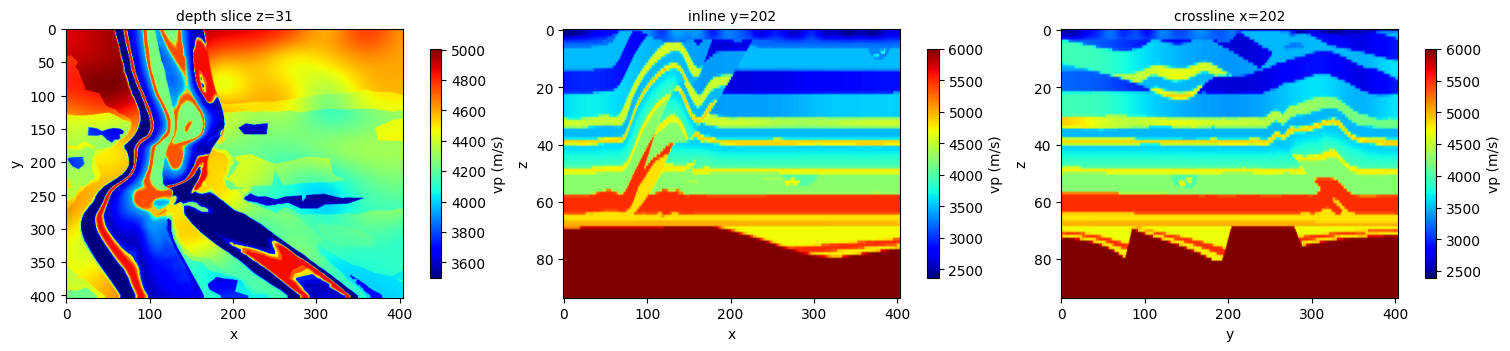

In [2]:
import matplotlib.pyplot as plt

nz, ny, nx = vp.shape
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4), constrained_layout=True)
for a, (img, ttl, xl, yl) in zip(ax, (
        (vp[nz//3], f"depth slice z={nz//3}", "x", "y"),
        (vp[:, ny//2, :], f"inline y={ny//2}", "x", "z"),
        (vp[:, :, nx//2], f"crossline x={nx//2}", "y", "z"))):
    im = a.imshow(img, cmap="jet", aspect="auto", origin="upper")
    a.set_title(ttl, fontsize=10); a.set_xlabel(xl); a.set_ylabel(yl)
    plt.colorbar(im, ax=a, shrink=0.85, label="vp (m/s)")
plt.show()

## Single-domain reference

One GPU, the whole model. This is the answer DD has to reproduce.

In [3]:
from sweep.equations import Acoustic3D
from sweep.propagator.torch import PropTorch

dev, so, abcn, nt, DT = torch.device("cuda:0"), 4, 20, 600, 0.002

def ricker(nt, dt, fm=8.0, delay=0.15):
    t = np.arange(nt, dtype=np.float32) * dt - delay
    a = np.pi * fm * t
    return ((1.0 - 2.0 * a**2) * np.exp(-(a**2))).astype(np.float32)

wav = torch.as_tensor(ricker(nt, DT), device=dev)
src = np.array([[[nx//2, ny//2, 4]]], dtype=np.int64)              # (x, y, z)
rec = np.array([[[ix, ny//2, 4] for ix in range(6, nx-6, 4)]], dtype=np.int64)

def build(shape):
    return PropTorch(Acoustic3D(spatial_order=so, device=dev, backend="torch"),
                     backend="torch", impl="c", shape=shape, dev=dev, dh=dh, dt=DT,
                     source_type=["h1"], receiver_type=["h1"], abcn=abcn,
                     free_surface=True, pml_type="cpmlr", nt=nt, B=1, use_ckpt=False,
                     boundary_saving_config={"enabled": True, "storage": "gpu",
                                             "transfer_interval": 1,
                                             "pinned_memory": False})

torch.cuda.reset_peak_memory_stats()
vp_ref = torch.tensor(vp, device=dev, requires_grad=True)
rec_ref = build(vp.shape)(wav, src, rec, models=[vp_ref])
(0.5 * rec_ref.pow(2).sum()).backward()
g_ref = vp_ref.grad.detach().cpu().numpy()
peak1 = torch.cuda.max_memory_allocated() / 2**30
print(f"single domain: record {tuple(rec_ref.shape)}  peak {peak1:.2f} GiB")
np.save("/tmp/ot_ref_grad.npy", g_ref)

single domain: record (1, 600, 98, 1)  peak 6.09 GiB


## Multi-tile DD

Launched as a subprocess — one rank per GPU. The worker re-runs the same shot
under `ModelParallel`, all-reduces the gradient, and compares against the
single-domain arrays saved above.

In [4]:
worker = r"""
import os, sys, numpy as np, torch, torch.distributed as dist
from sweep.datasets import load
from sweep.equations import Acoustic3D
from sweep.parallel import MeshTopology, pad_to_mesh
from sweep.parallel.dd_propagator import ModelParallel
from sweep.propagator.torch import PropTorch

dist.init_process_group("nccl")
rank, world = dist.get_rank(), dist.get_world_size()
li = int(os.environ.get("LOCAL_RANK", rank)) % max(1, torch.cuda.device_count())
torch.cuda.set_device(li); dev = torch.device(f"cuda:{li}")

py, px = int(sys.argv[1]), int(sys.argv[2])
d  = load("overthrust", variant="3d-acoustic", downsample=2)
vp = np.ascontiguousarray(d["vp"]).astype("float32"); dh = float(d["dh"][0])
TILE = 4                                   # must match the notebook's pad
vp = pad_to_mesh(vp, py=TILE, px=TILE)
nz, ny, nx = vp.shape
so, abcn, nt, DT = 4, 20, 600, 0.002

t = np.arange(nt, dtype=np.float32) * DT - 0.15
a = np.pi * 8.0 * t
wav = torch.as_tensor(((1 - 2*a**2) * np.exp(-a**2)).astype("float32"), device=dev)
src = np.array([[[nx//2, ny//2, 4]]], dtype=np.int64)
rec = np.array([[[ix, ny//2, 4] for ix in range(6, nx-6, 4)]], dtype=np.int64)

prop = PropTorch(Acoustic3D(spatial_order=so, device=dev, backend="torch"),
                 backend="torch", impl="c", shape=vp.shape, dev=dev, dh=dh, dt=DT,
                 source_type=["h1"], receiver_type=["h1"], abcn=abcn,
                 free_surface=True, pml_type="cpmlr", nt=nt, B=1, use_ckpt=False,
                 boundary_saving_config={"enabled": True, "storage": "gpu",
                                         "transfer_interval": 1, "pinned_memory": False})
mesh = MeshTopology(py=py, px=px, shot_groups=1, world_size=world, rank=rank)
ddp  = ModelParallel(prop, mesh)

torch.cuda.reset_peak_memory_stats()
vp_dd = torch.tensor(vp, device=dev, requires_grad=True)
rec_dd = ddp(wav, src, rec, models=[vp_dd])
(0.5 * rec_dd.pow(2).sum()).backward()
dist.all_reduce(vp_dd.grad)
peak = torch.cuda.max_memory_allocated() / 2**30

if rank == 0:
    g_ref = np.load("/tmp/ot_ref_grad.npy")
    g_dd  = vp_dd.grad.detach().cpu().numpy()
    dif   = np.abs(g_dd - g_ref)
    print(f"DD_RESULT py={py} px={px} peak_per_tile={peak:.2f}GiB "
          f"grad_bitexact={np.array_equal(g_dd, g_ref)} "
          f"max_abs_diff={dif.max():.3e} "
          f"rel_l2={np.linalg.norm(g_dd-g_ref)/(np.linalg.norm(g_ref)+1e-30):.3e}")
    np.save("/tmp/ot_dd_grad.npy", g_dd)
dist.barrier(); dist.destroy_process_group()
"""
import os, sys, subprocess, pathlib
pathlib.Path("/tmp/ot_dd_worker.py").write_text(worker)

ngpu = min(torch.cuda.device_count(), 4)
py, px = (2, 2) if ngpu == 4 else (1, ngpu)          # 4 GPUs -> both a y- and an x-cut
print(f"{ngpu}-way DD  (py={py}, px={px})")
env = dict(os.environ, PYTHONPATH=str(pathlib.Path(sweep.__file__).resolve().parents[1]))
res = subprocess.run([sys.executable, "-m", "torch.distributed.run", "--standalone",
                      f"--nproc-per-node={ngpu}", "/tmp/ot_dd_worker.py", str(py), str(px)],
                     capture_output=True, text=True, env=env)
out = res.stdout + res.stderr
for ln in out.splitlines():
    if "DD_RESULT" in ln:
        print(ln)
if res.returncode != 0:                     # show what actually went wrong
    print("--- subprocess failed, tail of its output ---")
    print("\n".join(out.strip().splitlines()[-15:]))
print("exit:", res.returncode)

4-way DD  (py=2, px=2)


DD_RESULT py=2 px=2 peak_per_tile=1.84GiB grad_bitexact=True max_abs_diff=0.000e+00 rel_l2=0.000e+00
exit: 0


## Does the gradient survive the cuts?

A halo or PML bug at a tile boundary shows up as a stripe *on the cut*, which a
global norm would average away. Plot the difference and slice straight across.

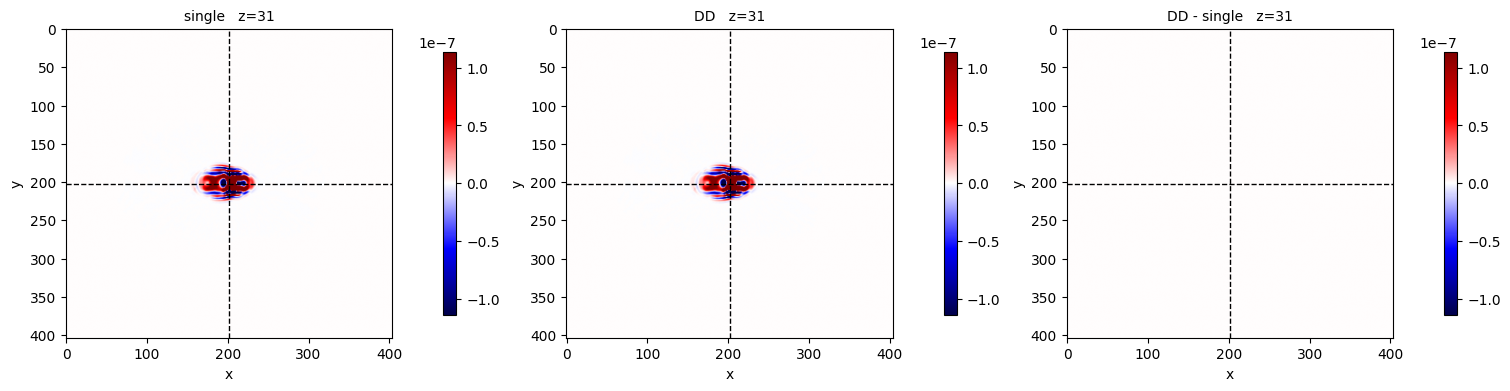

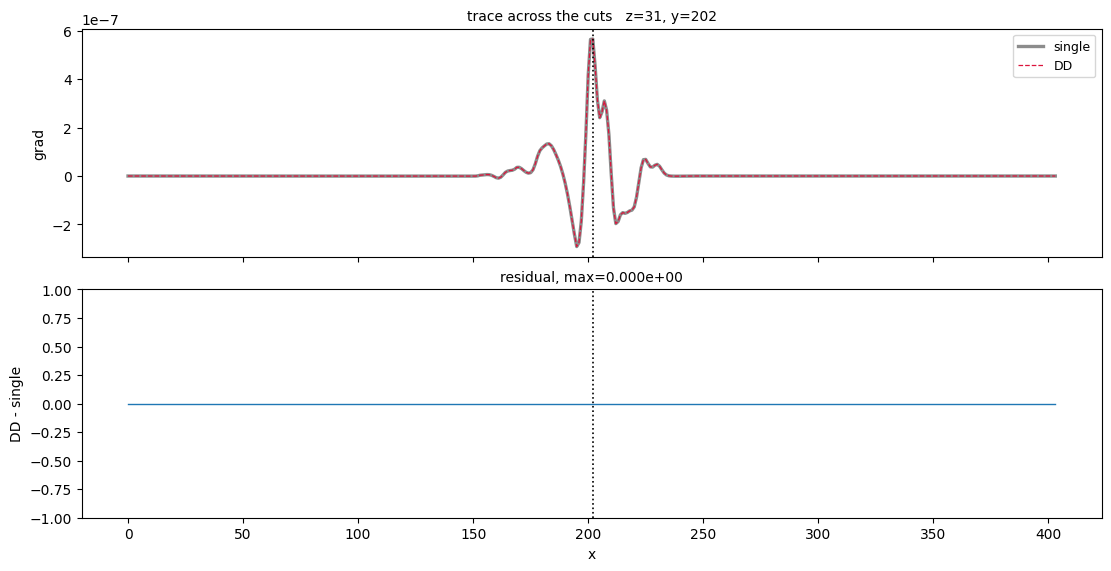

grad bit-exact : True
max |DD-single|: 0.000e+00


In [5]:
g_dd = np.load("/tmp/ot_dd_grad.npy")
cx, cy = nx // px, ny // py
cuts_x = [i * cx for i in range(1, px)]
cuts_y = [i * cy for i in range(1, py)]
iz = nz // 3

a, b = g_ref[iz], g_dd[iz]
v = np.percentile(np.abs(a), 99.5) or np.abs(a).max()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
for k, (img, ttl) in enumerate(((a, "single"), (b, "DD"), (b - a, "DD - single"))):
    im = ax[k].imshow(img, cmap="seismic", vmin=-v, vmax=v, aspect="auto", origin="upper")
    for c in cuts_x: ax[k].axvline(c, color="k", ls="--", lw=1.0)
    for c in cuts_y: ax[k].axhline(c, color="k", ls="--", lw=1.0)
    ax[k].set_title(f"{ttl}   z={iz}", fontsize=10)
    ax[k].set_xlabel("x"); ax[k].set_ylabel("y")
    plt.colorbar(im, ax=ax[k], shrink=0.85)
plt.show()

iy = cuts_y[0] if cuts_y else ny // 2
fig, ax = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, constrained_layout=True)
ax[0].plot(g_ref[iz, iy], lw=2.4, color="0.55", label="single")
ax[0].plot(g_dd[iz, iy], lw=0.9, color="crimson", ls="--", label="DD")
ax[0].set_ylabel("grad"); ax[0].legend(fontsize=9)
ax[0].set_title(f"trace across the cuts   z={iz}, y={iy}", fontsize=10)
r = g_dd[iz, iy] - g_ref[iz, iy]
ax[1].plot(r, lw=1.0, color="tab:blue")
ax[1].set_xlabel("x"); ax[1].set_ylabel("DD - single")
ax[1].set_title(f"residual, max={np.abs(r).max():.3e}", fontsize=10)
if np.abs(r).max() == 0.0: ax[1].set_ylim(-1, 1)
for a_ in ax:
    for c in cuts_x: a_.axvline(c, color="k", ls=":", lw=1.2)
plt.show()

print(f"grad bit-exact : {np.array_equal(g_dd, g_ref)}")
print(f"max |DD-single|: {np.abs(g_dd-g_ref).max():.3e}")

## What DD bought

`peak_per_tile` above is the per-GPU peak; compare it with the single-domain
peak printed earlier. DD trades a halo exchange per step for a model (and
wavefield, and boundary ring) that no longer has to fit on one card — which is
what makes 3-D field-scale grids reachable.

Two limits worth remembering:

* **Comm/compute overlap is x-cut only.** With a y-cut in the mesh the phased
  forward is switched off automatically and the serial path is used.
* **A source within `M` cells of an x-cut also disables overlap** (it would be
  injected after the strips were exchanged). Correctness is preserved either
  way — see `test/dd_src_on_cut_check.py`.
